# Adaptive Attention — Colab Training Notebook

**How this works:**
- Edit `.py` files locally in VSCode — Google Drive Desktop syncs them to Drive in seconds.
- Run cells here in Colab for GPU training.
- Checkpoints and results save into the Drive-synced repo folder and appear on your Mac automatically.

**One-time setup before first run:**
1. Install [Google Drive Desktop](https://www.google.com/drive/download/) on your Mac.
2. In Drive Desktop Preferences → My Computer → Add Folder → select your local repo folder.
3. In Google Drive (browser), right-click the teammate's `flickr8k` folder → Organize → Add shortcut to My Drive.

In [16]:
!ls "/content/drive/Othercomputers/My Mac/Neural_Image_Caption_Generator/"

checkpoints  data	  notebook     requirements.txt  train_adaptive.py
code	     evaluate.py  notebooks    results		 train.py
config.py    model.py	  __pycache__  scripts		 utils
conftest.py  models	  README.md    tests		 visualize.py


In [2]:
# ── Cell 1: Mount Drive and point to your local repo ─────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, sys
from pathlib import Path

# Your repo folder as synced by Google Drive Desktop.
# Change the Mac name below only if your computer name is different.
REPO_DIR = Path("/content/drive/Othercomputers/My Mac/Neural_Image_Caption_Generator/")

assert REPO_DIR.exists(), (
    f"Repo not found at {REPO_DIR}.\n"
    "Make sure Google Drive Desktop is running on your Mac and has synced the repo folder."
)

os.chdir(REPO_DIR)
sys.path.insert(0, str(REPO_DIR))
print('Repo:', REPO_DIR)

!pip install -q -r requirements.txt
import torch
print('CUDA:', torch.cuda.is_available(), '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'no GPU')

Mounted at /content/drive
Repo: /content/drive/Othercomputers/My Mac/Neural_Image_Caption_Generator
CUDA: True | Tesla T4


In [3]:
# ── Cell 2: Copy Flickr8k from Drive to VM local storage (~1-2 min) ──────────
# Data is copied to VM-local disk so image reads during training are fast.
# This runs once per Colab session.
#
# Assumes you added a shortcut: My Drive / flickr8k
# Update DRIVE_DATA below if your shortcut has a different name.

import shutil

DRIVE_DATA = Path('/content/drive/MyDrive/flickr8k')
VM_DATA    = Path('/content/flickr8k')

assert DRIVE_DATA.exists(), (
    f"Data not found at {DRIVE_DATA}.\n"
    "In Google Drive, right-click the teammate's flickr8k folder → "
    "Organize → Add shortcut to My Drive."
)

if not VM_DATA.exists():
    print('Copying dataset to VM... (this takes ~1-2 min)')
    shutil.copytree(str(DRIVE_DATA), str(VM_DATA))
    print('Done.')
else:
    print('Dataset already on VM.')

os.environ['FLICKR8K_ROOT'] = str(VM_DATA)
print('FLICKR8K_ROOT =', VM_DATA)

Copying dataset to VM... (this takes ~1-2 min)
Done.
FLICKR8K_ROOT = /content/flickr8k


In [4]:
# ── Cell 3: Validate dataset ──────────────────────────────────────────────────
from utils import validate_dataset_layout
validate_dataset_layout(str(VM_DATA))
print('Dataset OK.')

Dataset OK.


In [5]:
# ── Cell 4: Enable autoreload ─────────────────────────────────────────────────
# Upgrade IPython first — older versions use `imp` which was removed in Python 3.12.
!pip install -q --upgrade ipython
%load_ext autoreload
%autoreload 2
print('Autoreload enabled.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.3/627.3 kB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 9.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.13.0 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.2.1 which is incompatible.
Autoreload enabled.


In [6]:
# ── Lambda config — change this to run a different regularization strength ────
# Results are saved with a lam-suffix so runs don't overwrite each other.
# e.g. LAM=1.0  → training_log_adaptive_lam1.csv, adaptive_best_lam1.pt
#      LAM=0.01 → training_log_adaptive_lam0.01.csv, adaptive_best_lam0.01.pt
LAM = 0.01

# Set True to skip training and reuse the existing checkpoint from Drive.
# Set False to train from scratch.
SKIP_TRAINING = True

## Train

Set `LAM` in the config cell above before running.  
Checkpoints → `checkpoints/adaptive_best_lam{LAM}.pt`  
Training log → `results/training_log_adaptive_lam{LAM}.csv`

In [7]:
from pathlib import Path

ckpt = Path(f'checkpoints/adaptive_best_lam{LAM}.pt')
if SKIP_TRAINING:
    if ckpt.exists():
        print(f'Skipping training — checkpoint already exists: {ckpt}')
    else:
        print(f'WARNING: SKIP_TRAINING=True but no checkpoint found at {ckpt}')
        print('Set SKIP_TRAINING=False in the config cell to train from scratch.')
else:
    # get_ipython().system() is identical to the ! magic — output streams live
    get_ipython().system(f'FLICKR8K_ROOT=/content/flickr8k python train_adaptive.py --lam {LAM}')

Skipping training — checkpoint already exists: checkpoints/adaptive_best_lam0.01.pt


## Evaluate

In [8]:
!FLICKR8K_ROOT=/content/flickr8k python evaluate.py \
  --checkpoint checkpoints/adaptive_best_lam{LAM}.pt \
  --data_root /content/flickr8k \
  --vocab /content/flickr8k/vocab.json \
  --split test \
  --batch_size 64 \
  --results_out results/test_bleu_adaptive_lam{LAM}.json

Loading vocabulary from /content/flickr8k/vocab.json...
Loading checkpoint from checkpoints/adaptive_best_lam0.01.pt...
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100% 528M/528M [00:07<00:00, 70.3MB/s]
Detected adaptive-attention checkpoint — using AdaptiveDecoder.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Evaluating [test]:   0% 0/16 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker 

## Visualize Attention

Each subplot shows the word and `β=0.xx` — the sentinel weight at that step.  
High β means the model relied on language statistics rather than the image.

In [9]:
!FLICKR8K_ROOT=/content/flickr8k python visualize.py \
  --checkpoint checkpoints/adaptive_best_lam{LAM}.pt \
  --vocab /content/flickr8k/vocab.json \
  --data_root /content/flickr8k \
  --split test \
  --num_examples 6 \
  --output_dir results/attention_examples_adaptive_lam{LAM} \
  --overlay_style paper \
  --dpi 200 \
  --also_sentence \
  --save_json \
  --lam {LAM}

Detected adaptive-attention checkpoint — sentinel weights (β) will be shown.
Processing: /content/flickr8k/images/1003163366_44323f5815.jpg
  Caption: a man and a dog are sitting on a bench
Saved attention figure → results/attention_examples_adaptive_lam0.01/1003163366_44323f5815_attention.png
Saved sentence figure → results/attention_examples_adaptive_lam0.01/1003163366_44323f5815_sentence.png
Processing: /content/flickr8k/images/1007129816_e794419615.jpg
  Caption: a man wearing a colorful hat and hat
Saved attention figure → results/attention_examples_adaptive_lam0.01/1007129816_e794419615_attention.png
Saved sentence figure → results/attention_examples_adaptive_lam0.01/1007129816_e794419615_sentence.png
Processing: /content/flickr8k/images/1019077836_6fc9b15408.jpg
  Caption: a dog is running through a field
Saved attention figure → results/attention_examples_adaptive_lam0.01/1019077836_6fc9b15408_attention.png
Saved sentence figure → results/attention_examples_adaptive_lam0.01/101

In [10]:
from IPython.display import Image, display
from pathlib import Path
for p in sorted(Path(f'results/attention_examples_adaptive_lam{LAM}').glob('*.png'))[:6]:
    print(p.name)
    display(Image(filename=str(p)))

Output hidden; open in https://colab.research.google.com to view.

### Sentence β Visualization

Each word is colored by its sentinel weight β.  
**Blue** = model looked at the image to produce this word.  
**Red** = model relied on the language model sentinel (typically function words: *a*, *the*, *is*).

In [11]:
from IPython.display import Image, display
from pathlib import Path

sent_dir = Path(f'results/attention_examples_adaptive_lam{LAM}')
sent_figs = sorted(sent_dir.glob('*_sentence.png'))

if not sent_figs:
    print('No sentence figures found. Run the visualize cell above first.')
else:
    for p in sent_figs[:6]:
        print(p.name)
        display(Image(filename=str(p)))

Output hidden; open in https://colab.research.google.com to view.

## Sentinel Weight Analysis

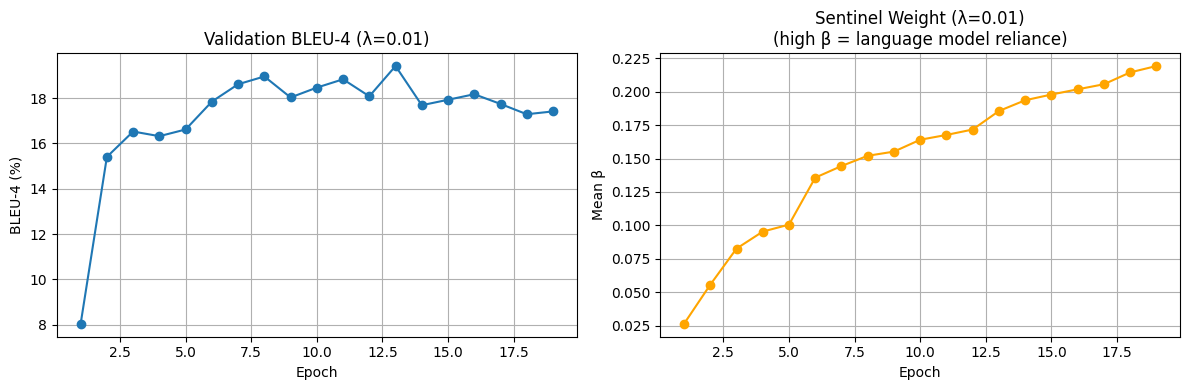

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv(f'results/training_log_adaptive_lam{LAM}.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log['epoch'], log['val_bleu4'] * 100, marker='o')
axes[0].set(xlabel='Epoch', ylabel='BLEU-4 (%)', title=f'Validation BLEU-4 (λ={LAM})')
axes[0].grid(True)

axes[1].plot(log['epoch'], log['mean_beta'], marker='o', color='orange')
axes[1].set(xlabel='Epoch', ylabel='Mean β', title=f'Sentinel Weight (λ={LAM})\n(high β = language model reliance)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'results/adaptive_training_curves_lam{LAM}.png', dpi=150)
plt.show()

## Lambda Comparison

Aggregates all completed runs (any `test_bleu_adaptive_lam*.json` + matching training log)
and plots how λ affects BLEU-4 and sentinel activation.  
Run this cell after completing two or more λ runs.

 lambda  test_bleu4  best_val_bleu4  mean_beta_final
   0.01   19.813708         19.4147         0.207838
   1.00   18.800518         19.0910         0.000001


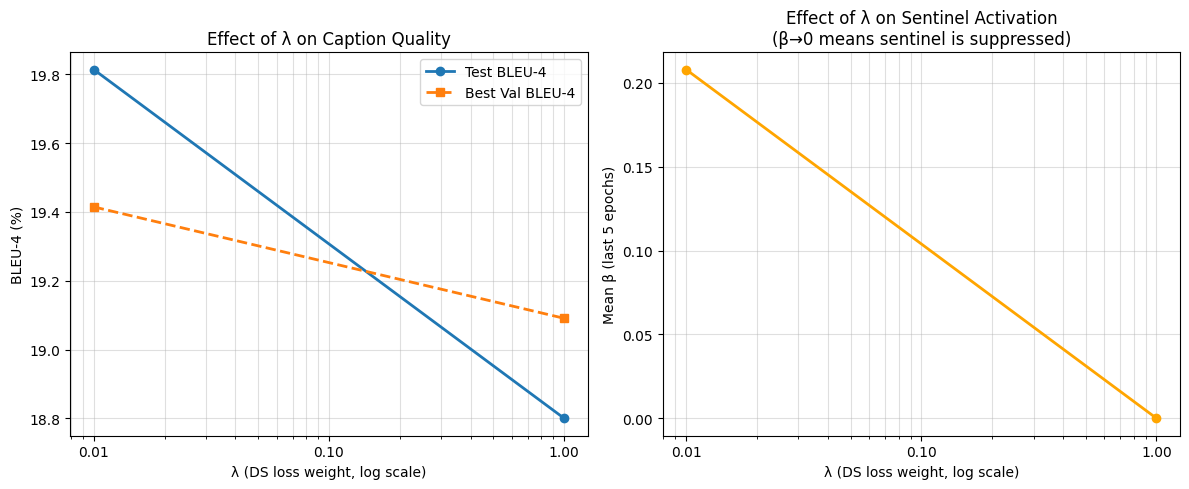

Saved → results/lambda_comparison.png


In [13]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

results_dir = Path('results')

rows = []
for bleu_file in sorted(results_dir.glob('test_bleu_adaptive_lam*.json')):
    m = re.search(r'lam([\d.eE+-]+)\.json$', bleu_file.name)
    if not m:
        continue
    lam_val = float(m.group(1))
    with open(bleu_file) as f:
        bleu = json.load(f)['scores']

    log_file = results_dir / f'training_log_adaptive_lam{m.group(1)}.csv'
    if not log_file.exists():
        continue
    log = pd.read_csv(log_file)
    mean_beta_final = log['mean_beta'].iloc[-5:].mean()   # avg over last 5 epochs
    best_val_bleu4  = log['val_bleu4'].max()

    rows.append({
        'lambda':          lam_val,
        'test_bleu4':      bleu['bleu4'] * 100,
        'best_val_bleu4':  best_val_bleu4 * 100,
        'mean_beta_final': mean_beta_final,
    })

if not rows:
    print('No completed runs found yet. Run at least one λ value first.')
else:
    df = pd.DataFrame(rows).sort_values('lambda')
    print(df.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: BLEU-4 vs lambda
    axes[0].plot(df['lambda'], df['test_bleu4'], marker='o', linewidth=2, label='Test BLEU-4')
    axes[0].plot(df['lambda'], df['best_val_bleu4'], marker='s', linestyle='--', linewidth=2, label='Best Val BLEU-4')
    axes[0].set_xscale('log')
    axes[0].set(xlabel='λ (DS loss weight, log scale)', ylabel='BLEU-4 (%)', title='Effect of λ on Caption Quality')
    axes[0].legend()
    axes[0].grid(True, which='both', alpha=0.4)
    axes[0].xaxis.set_major_formatter(ticker.ScalarFormatter())

    # Panel 2: Mean β vs lambda
    axes[1].plot(df['lambda'], df['mean_beta_final'], marker='o', color='orange', linewidth=2)
    axes[1].set_xscale('log')
    axes[1].set(xlabel='λ (DS loss weight, log scale)', ylabel='Mean β (last 5 epochs)',
                title='Effect of λ on Sentinel Activation\n(β→0 means sentinel is suppressed)')
    axes[1].grid(True, which='both', alpha=0.4)
    axes[1].xaxis.set_major_formatter(ticker.ScalarFormatter())

    plt.tight_layout()
    plt.savefig('results/lambda_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → results/lambda_comparison.png')

## Cross-Lambda Sentence Comparison

For each image that was visualized in multiple λ runs, shows the generated caption
side-by-side with β coloring — one row per λ value.  
Run after completing at least two λ runs and their visualize steps.

In [14]:
import json, re, math
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import Image as IPImage, display

results_dir = Path('results')

# ── Load caption JSONs grouped by lambda and image name ─────────────────────
lam_data = {}  # {lam_val: {img_name: {caption, betas}}}

for lam_dir in sorted(results_dir.glob('attention_examples_adaptive_lam*')):
    m = re.search(r'lam([\d.eE+-]+)$', lam_dir.name)
    if not m:
        continue
    lam_val = float(m.group(1))
    lam_data[lam_val] = {}
    for jf in sorted(lam_dir.glob('*_caption.json')):
        with open(jf) as f:
            d = json.load(f)
        lam_data[lam_val][d['image']] = {'caption': d['caption'], 'betas': d['betas']}

if len(lam_data) < 2:
    print(f'Only {len(lam_data)} lambda run(s) with JSON data found. '
          f'Run the visualize cell (with --save_json) for at least two λ values.')
else:
    common_imgs = sorted(set.intersection(*[set(v.keys()) for v in lam_data.values()]))
    lam_vals    = sorted(lam_data.keys())
    print(f'Found {len(common_imgs)} images common across λ = {lam_vals}')

    WORDS_PER_ROW = 8
    cmap = plt.cm.coolwarm
    norm = plt.Normalize(vmin=0.0, vmax=1.0)

    for img_name in common_imgs[:4]:   # up to 4 images
        n_lams   = len(lam_vals)
        max_rows = max(math.ceil(len(lam_data[lv][img_name]['caption']) / WORDS_PER_ROW)
                       for lv in lam_vals)
        row_h    = max(1.8, 0.9 + max_rows * 1.2)

        fig, axes = plt.subplots(n_lams, 1, figsize=(14, row_h * n_lams + 0.6))
        if n_lams == 1:
            axes = [axes]
        fig.suptitle(f'Image: {img_name}', fontsize=11, y=1.01)

        for ax, lv in zip(axes, lam_vals):
            words     = lam_data[lv][img_name]['caption']
            betas_arr = np.array(lam_data[lv][img_name]['betas'])
            n_rows    = math.ceil(len(words) / WORDS_PER_ROW)

            ax.set_xlim(0, WORDS_PER_ROW)
            ax.set_ylim(-(n_rows - 0.4), 1.0)
            ax.axis('off')
            mean_b = betas_arr.mean()
            ax.set_title(f'λ = {lv}   (mean β = {mean_b:.3f})', fontsize=10, loc='left', pad=3)

            for idx, (word, beta) in enumerate(zip(words, betas_arr)):
                col = idx % WORDS_PER_ROW
                row = idx // WORDS_PER_ROW
                x, y = col + 0.5, -row

                bg  = cmap(norm(beta))
                lum = 0.299 * bg[0] + 0.587 * bg[1] + 0.114 * bg[2]
                tc  = 'white' if lum < 0.50 else 'black'

                ax.text(x, y + 0.12, word, ha='center', va='center',
                        fontsize=11, fontweight='bold', color=tc,
                        bbox=dict(boxstyle='round,pad=0.32', facecolor=bg,
                                  edgecolor='none', alpha=0.92), zorder=3)
                ax.text(x, y - 0.32, f'β={beta:.2f}', ha='center', va='center',
                        fontsize=7, color='#666666')

        plt.tight_layout()
        out_path = f'results/cross_lambda_{img_name}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {out_path}')
        display(IPImage(filename=out_path))
        plt.close(fig)

Found 0 images common across λ = [0.01, 1.0]


## BLEU Score Table & Bar Chart

Full BLEU-1 through BLEU-4 breakdown for every completed λ run, plus mean β.

   λ  BLEU-1  BLEU-2  BLEU-3  BLEU-4  mean β
0.01   62.17   43.42   29.45   19.81  0.2078
1.00   62.37   43.60   29.06   18.80  0.0000


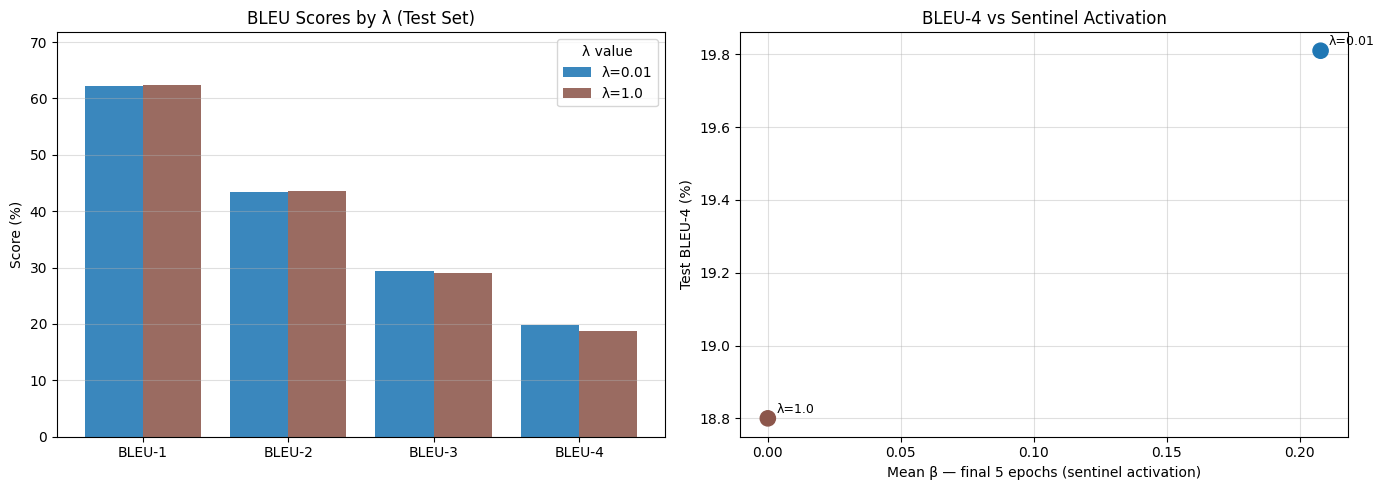

Saved → results/bleu_table_chart.png


In [15]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

results_dir = Path('results')

rows = []
for bleu_file in sorted(results_dir.glob('test_bleu_adaptive_lam*.json')):
    m = re.search(r'lam([\d.eE+-]+)\.json$', bleu_file.name)
    if not m:
        continue
    lam_str = m.group(1)
    lam_val = float(lam_str)
    with open(bleu_file) as f:
        scores = json.load(f)['scores']

    log_file = results_dir / f'training_log_adaptive_lam{lam_str}.csv'
    mean_beta = float('nan')
    if log_file.exists():
        log = pd.read_csv(log_file)
        mean_beta = log['mean_beta'].iloc[-5:].mean()

    rows.append({
        'λ':       lam_val,
        'BLEU-1':  round(scores['bleu1'] * 100, 2),
        'BLEU-2':  round(scores['bleu2'] * 100, 2),
        'BLEU-3':  round(scores['bleu3'] * 100, 2),
        'BLEU-4':  round(scores['bleu4'] * 100, 2),
        'mean β':  round(mean_beta, 4),
    })

if not rows:
    print('No completed test-evaluation runs found.')
else:
    df = pd.DataFrame(rows).sort_values('λ').reset_index(drop=True)

    # ── Styled table ─────────────────────────────────────────────────────────
    print('=' * 58)
    print(df.to_string(index=False))
    print('=' * 58)

    # ── Grouped bar chart: BLEU-1 to BLEU-4 per lambda ───────────────────────
    metrics = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
    x       = np.arange(len(metrics))
    width   = 0.8 / len(df)
    colors  = plt.cm.tab10(np.linspace(0, 0.5, len(df)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, (_, row) in enumerate(df.iterrows()):
        offset = (i - len(df) / 2 + 0.5) * width
        axes[0].bar(x + offset, [row[m] for m in metrics],
                    width=width, label=f'λ={row["λ"]}', color=colors[i], alpha=0.88)

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(metrics)
    axes[0].set_ylabel('Score (%)')
    axes[0].set_title('BLEU Scores by λ (Test Set)')
    axes[0].legend(title='λ value')
    axes[0].grid(axis='y', alpha=0.4)
    axes[0].set_ylim(0, max(df['BLEU-1']) * 1.15)

    # ── Scatter: BLEU-4 vs mean β ─────────────────────────────────────────────
    axes[1].scatter(df['mean β'], df['BLEU-4'], s=120, c=colors[:len(df)], zorder=3)
    for _, row in df.iterrows():
        axes[1].annotate(f'λ={row["λ"]}', (row['mean β'], row['BLEU-4']),
                         textcoords='offset points', xytext=(6, 4), fontsize=9)
    axes[1].set_xlabel('Mean β — final 5 epochs (sentinel activation)')
    axes[1].set_ylabel('Test BLEU-4 (%)')
    axes[1].set_title('BLEU-4 vs Sentinel Activation')
    axes[1].grid(alpha=0.4)

    plt.tight_layout()
    plt.savefig('results/bleu_table_chart.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → results/bleu_table_chart.png')